<a href="https://colab.research.google.com/github/suzannelittle/dcu-dpv/blob/main/NamesTemplate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Template to get started exploring names datasets
Suzanne Little    
suzanne.little@dcu.ie    
https://github.com/DiversityInData/Python-Workshops/tree/master/Visualisation    

In [ ]:
# get the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

Load the US Baby Names dataset

In [ ]:
usn = pd.read_csv("https://raw.githubusercontent.com/suzannelittle/Python-Workshops/master/Visualisation/datasets/usnames.csv")
# NOTE: see also the UK or Irish baby names datasets (much smaller) - https://github.com/suzannelittle/Python-Workshops/tree/master/Visualisation/datasets
#usn = pd.read_csv("https://raw.githubusercontent.com/suzannelittle/Python-Workshops/master/Visualisation/datasets/irishnames.csv")
#usn = pd.read_csv("https://raw.githubusercontent.com/suzannelittle/Python-Workshops/master/Visualisation/datasets/nswbabynames.csv")
#usn = pd.read_csv("https://raw.githubusercontent.com/suzannelittle/Python-Workshops/master/Visualisation/datasets/uknames.csv")
usn.head()

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


In [ ]:
usn.describe()

,births,year
count,1.924665e+06,1.924665e+06
mean,1.808733e+02,1.974851e+03
std,1.533337e+03,3.402948e+01
min,5.000000e+00,1.880000e+03
25%,7.000000e+00,1.951000e+03
50%,1.200000e+01,1.985000e+03
75%,3.200000e+01,2.003000e+03
max,9.968600e+04,2.017000e+03


In [ ]:
def add_prop(group):
    # Integer division floors
    births = group.births.astype(float)
    group['prop'] = births / births.sum()
    return group
usn = usn.groupby(['year', 'sex'], group_keys=False).apply(add_prop)

In [ ]:
usn.head()

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077643
1,Anna,F,2604,1880,0.028618
2,Emma,F,2003,1880,0.022013
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188


In [ ]:
myname = usn[(usn.name == "Suzanne") & (usn.sex == "F")]
myname.describe()

,births,year,prop
count,137.000000,137.000000,137.000000
mean,1597.255474,1948.978102,0.000991
std,2080.319510,39.730057,0.001165
min,5.000000,1880.000000,0.000027
25%,77.000000,1915.000000,0.000075
50%,424.000000,1949.000000,0.000308
75%,2508.000000,1983.000000,0.001853
max,6855.000000,2017.000000,0.003786


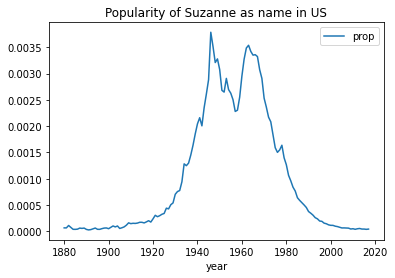

In [ ]:
myname.plot(x='year', y='prop', title="Popularity of Suzanne as name in US")

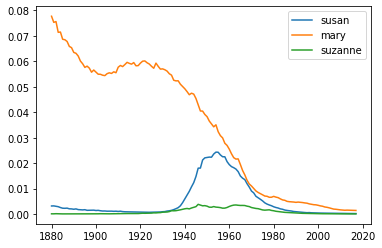

In [ ]:
susan = usn[(usn.name == "Susan") & (usn.sex == "F")][['year', 'prop']]
mary = usn[(usn.name == "Mary") & (usn.sex == "F")][['year', 'prop']]
plt.plot(susan.year, susan.prop, label="susan")
plt.plot(mary.year, mary.prop, label="mary")
plt.plot(myname.year, myname.prop, label="suzanne")
plt.legend(loc='upper right')
plt.show()